# 10 — Policy Scenario Comparison

Runs NSGA-II evolution under 5 different policy scenarios and compares:
- Pareto fronts (all overlaid)
- Action maps per scenario
- Summary statistics

Uses the learned carbon model with pre-computed forest GBR predictions.

**Expected runtime:** ~40-60 min total (5 scenarios × 200 pop × 200 gen)

In [1]:
import sys
sys.path.insert(0, "../src")

import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import time
from copy import deepcopy

from estonia_landuse.optimizer.trainer import train as run_evolution
from estonia_landuse.simulator.config import default_config
from estonia_landuse.simulator.simulator import summarize_policy

## Configuration

In [2]:
POP_SIZE = 200
N_GENERATIONS = 200

OUTPUT_DIR = Path("../data/processed/learned_carbon")

## Load data

All features pre-computed by notebook 09 (includes forest, peat, rohemeeter).

In [3]:
features_df = pd.read_parquet(OUTPUT_DIR / "features_with_forest.parquet")

# Compute GBR predictions if not already in the parquet
if "predicted_tco2_ha_yr" not in features_df.columns:
    from carbon_dataset.forest_carbon_model import load_model, FEATURE_COLS as GBR_FEATURES
    from carbon_dataset.config import WOOD_DENSITY, CARBON_FRACTION, CO2_PER_C, BEF
    try:
        gbr = load_model()
        # Predict from available forest features (fallback if columns missing)
        from carbon_dataset.forest_carbon_model import predict_tco2
        features_df["predicted_tco2_ha_yr"] = predict_tco2(gbr, features_df)
        print(f"GBR predictions computed: mean={features_df['predicted_tco2_ha_yr'].mean():.2f}")
    except Exception as e:
        # Fallback: use juurdekasv conversion or NIR default
        if "mean_increment" in features_df.columns:
            features_df["predicted_tco2_ha_yr"] = features_df["mean_increment"] * 0.42 * CARBON_FRACTION * CO2_PER_C * BEF
        else:
            features_df["predicted_tco2_ha_yr"] = 3.8
        print(f"GBR failed ({e}), using fallback")
    features_df["predicted_tco2_ha_yr"] = features_df["predicted_tco2_ha_yr"].fillna(3.8)

# Feature columns for prescriptor
FEATURE_COLUMNS = [
    "urban_pct", "agriculture_pct", "grassland_pct", "forest_pct",
    "wetland_pct", "water_pct", "naturalness_score", "carbon_score",
    "protected_overlap_pct", "wetland_suitability", "biodiversity_proxy",
    "opportunity_cost_proxy", "rohemeeter_norm",
]
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c in features_df.columns]

# Grid for maps
grid = gpd.read_file("../data/processed/v1/base_grid.gpkg")
print(f"Loaded: {len(features_df)} cells, {len(FEATURE_COLUMNS)} features")
print(f"  peat_overlap_pct: mean={features_df['peat_overlap_pct'].mean():.3f}, >0: {(features_df['peat_overlap_pct']>0).sum()}")
print(f"  rohemeeter_norm: mean={features_df.get('rohemeeter_norm', pd.Series(0)).mean():.3f}")

GBR failed ("None of [Index(['peapuuliik', 'keskmVanus', 'boniteediKood', 'kuivendatud',\n       'kasvukohaKood', 'pindala', 'korgus'],\n      dtype='str')] are in the [columns]"), using fallback
Loaded: 11224 cells, 13 features
  peat_overlap_pct: mean=0.236, >0: 4998
  rohemeeter_norm: mean=0.537


## Define scenarios

In [4]:
def make_scenario_config(scenario_name):
    """Create a config dict for each scenario with aggressive differentiation."""
    config = default_config()
    config["carbon_model"] = "learned"

    if scenario_name == "green_maximum":
        # Maximum ecological gain — relax all economic constraints
        config["scoring"]["agriculture_loss_cost"] = 0.3
        config["max_total_agri_loss_pct"] = 0.50
        config["max_changed_pct"] = 0.40
        config["budget_penalty_weight"] = 3.0
        config["total_agri_loss_penalty_weight"] = 5.0

    elif scenario_name == "food_security":
        # Preserve farmland at all costs
        config["scoring"]["agriculture_loss_cost"] = 15.0
        config["max_total_agri_loss_pct"] = 0.03
        config["total_agri_loss_penalty_weight"] = 100.0
        config["max_changed_pct"] = 0.15

    elif scenario_name == "low_budget":
        # Minimal intervention — what can you achieve cheaply?
        config["max_changed_pct"] = 0.06
        config["budget_penalty_weight"] = 50.0
        config["scoring"]["base_change_cost"] = 2.0

    elif scenario_name == "wetland_priority":
        # Prioritize wetland restoration — relax constraints on wetland
        config["constraints"]["wetland_suit_min_for_restore"] = 0.05
        config["scoring"]["biodiversity_value"] = [0.4, 1.0, 0.1, 0.3]
        config["max_changed_pct"] = 0.25
        config["budget_penalty_weight"] = 5.0

    elif scenario_name == "balanced":
        pass  # default config

    return config


SCENARIOS = {
    "green_maximum": "Green Maximum (low agri protection)",
    "food_security": "Food Security (preserve farmland)",
    "low_budget": "Low Budget (minimal intervention)",
    "wetland_priority": "Wetland Priority (rewetting focus)",
    "balanced": "Balanced (default)",
}

print("Scenarios defined:")
for key, desc in SCENARIOS.items():
    print(f"  {key}: {desc}")

Scenarios defined:
  green_maximum: Green Maximum (low agri protection)
  food_security: Food Security (preserve farmland)
  low_budget: Low Budget (minimal intervention)
  wetland_priority: Wetland Priority (rewetting focus)
  balanced: Balanced (default)


## Run evolution for each scenario

In [5]:
results = {}
for scenario_name, description in SCENARIOS.items():
    config = make_scenario_config(scenario_name)

    print(f"\n{'='*60}")
    print(f"Scenario: {description}")
    print(f"  pop={POP_SIZE}, gen={N_GENERATIONS}")
    t0 = time.time()

    pop = run_evolution(
        context=features_df,
        feature_columns=FEATURE_COLUMNS,
        pop_size=POP_SIZE,
        n_generations=N_GENERATIONS,
        config=config,
        verbose=True,
    )

    dt = time.time() - t0
    front0 = [p for p in pop if p.rank == 0]
    results[scenario_name] = {
        "pop": pop, "front0": front0, "config": config,
        "time": dt, "description": description,
    }
    print(f"  Done in {dt:.0f}s, front-0: {len(front0)}")

print(f"\n\nTotal time: {sum(r['time'] for r in results.values())/60:.1f} min")


Scenario: Green Maximum (low agri protection)
  pop=200, gen=200


C:\Users\risto\projects\et-landuse-neuroevolution\notebooks\../src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0:  22 | Avg: bio=0.0123 carbon=-0.0093 cost=1.2691 change=19.5%
Gen  20 | Front-0:  79 | Avg: bio=0.0252 carbon=0.0115 cost=0.9176 change=15.0%
Gen  30 | Front-0: 200 | Avg: bio=0.0333 carbon=0.0180 cost=1.0929 change=14.6%
Gen  40 | Front-0: 200 | Avg: bio=0.0354 carbon=0.0184 cost=1.3619 change=14.4%
Gen  50 | Front-0: 200 | Avg: bio=0.0351 carbon=0.0177 cost=1.4648 change=13.3%
Gen  60 | Front-0: 200 | Avg: bio=0.0339 carbon=0.0177 cost=1.4613 change=13.0%
Gen  70 | Front-0: 200 | Avg: bio=0.0379 carbon=0.0197 cost=1.6814 change=13.2%
Gen  80 | Front-0: 200 | Avg: bio=0.0356 carbon=0.0184 cost=1.5627 change=12.4%
Gen  90 | Front-0: 200 | Avg: bio=0.0354 carbon=0.0180 cost=1.6130 change=12.4%
Gen 100 | Front-0: 200 | Avg: bio=0.0362 carbon=0.0183 cost=1.6902 change=12.4%
Gen 110 | Front-0: 200 | Avg: bio=0.0376 carbon=0.0192 cost=1.6508 change=12.7%
Gen 120 | Front-0: 200 | Avg: bio=0.0375 carbon=0.0190 cost=1.5917 change=12.4%
Gen 130 | F

C:\Users\risto\projects\et-landuse-neuroevolution\notebooks\../src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0:  41 | Avg: bio=0.0011 carbon=-0.0220 cost=12.7722 change=21.5%
Gen  20 | Front-0: 104 | Avg: bio=0.0352 carbon=0.0131 cost=22.1429 change=17.5%
Gen  30 | Front-0: 200 | Avg: bio=0.0405 carbon=0.0212 cost=22.7391 change=16.0%
Gen  40 | Front-0: 200 | Avg: bio=0.0289 carbon=0.0153 cost=24.8782 change=14.0%
Gen  50 | Front-0: 200 | Avg: bio=0.0297 carbon=0.0153 cost=26.1076 change=13.6%
Gen  60 | Front-0: 200 | Avg: bio=0.0326 carbon=0.0164 cost=28.0418 change=13.4%
Gen  70 | Front-0: 200 | Avg: bio=0.0315 carbon=0.0164 cost=29.0432 change=13.0%
Gen  80 | Front-0: 200 | Avg: bio=0.0333 carbon=0.0172 cost=31.6326 change=13.0%
Gen  90 | Front-0: 200 | Avg: bio=0.0309 carbon=0.0159 cost=28.9229 change=12.5%
Gen 100 | Front-0: 200 | Avg: bio=0.0332 carbon=0.0172 cost=32.4713 change=12.3%
Gen 110 | Front-0: 200 | Avg: bio=0.0335 carbon=0.0177 cost=31.5139 change=12.4%
Gen 120 | Front-0: 200 | Avg: bio=0.0329 carbon=0.0175 cost=33.7131 change=12.1%

...

Created 4 seed prescriptors
Gen  10 | Front-0:  14 | Avg: bio=0.0126 carbon=-0.0097 cost=10.6956 change=19.5%
Gen  20 | Front-0:  94 | Avg: bio=0.0389 carbon=0.0164 cost=11.1632 change=16.7%
Gen  30 | Front-0: 200 | Avg: bio=0.0496 carbon=0.0236 cost=11.2146 change=16.4%
Gen  40 | Front-0: 200 | Avg: bio=0.0483 carbon=0.0239 cost=10.2782 change=15.0%
Gen  50 | Front-0: 200 | Avg: bio=0.0440 carbon=0.0221 cost=9.3726 change=13.5%
Gen  60 | Front-0: 200 | Avg: bio=0.0410 carbon=0.0212 cost=8.9921 change=12.8%
Gen  70 | Front-0: 200 | Avg: bio=0.0395 carbon=0.0209 cost=9.4602 change=12.3%
Gen  80 | Front-0: 200 | Avg: bio=0.0388 carbon=0.0201 cost=9.2278 change=12.1%
Gen  90 | Front-0: 200 | Avg: bio=0.0385 carbon=0.0197 cost=9.8472 change=11.9%
Gen 100 | Front-0: 200 | Avg: bio=0.0379 carbon=0.0191 cost=9.5611 change=11.8%
Gen 110 | Front-0: 200 | Avg: bio=0.0385 carbon=0.0193 cost=10.1687 change=11.9%
Gen 120 | Front-0: 200 | Avg: bio=0.0391 carbon=0.0197 cost=10.0453 change=12.2%
Gen 1

C:\Users\risto\projects\et-landuse-neuroevolution\notebooks\../src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0:  33 | Avg: bio=0.0095 carbon=-0.0130 cost=2.4960 change=19.1%
Gen  20 | Front-0: 149 | Avg: bio=0.0226 carbon=0.0152 cost=2.8787 change=15.8%
Gen  30 | Front-0: 200 | Avg: bio=0.0240 carbon=0.0183 cost=3.4032 change=15.4%
Gen  40 | Front-0: 200 | Avg: bio=0.0227 carbon=0.0170 cost=4.5999 change=14.8%
Gen  50 | Front-0: 200 | Avg: bio=0.0219 carbon=0.0163 cost=5.2851 change=13.6%
Gen  60 | Front-0: 200 | Avg: bio=0.0223 carbon=0.0167 cost=5.8188 change=13.3%
Gen  70 | Front-0: 200 | Avg: bio=0.0217 carbon=0.0170 cost=5.6642 change=12.5%
Gen  80 | Front-0: 200 | Avg: bio=0.0224 carbon=0.0174 cost=6.3758 change=12.4%
Gen  90 | Front-0: 200 | Avg: bio=0.0227 carbon=0.0173 cost=6.4642 change=12.3%
Gen 100 | Front-0: 200 | Avg: bio=0.0227 carbon=0.0177 cost=6.7126 change=12.2%
Gen 110 | Front-0: 200 | Avg: bio=0.0210 carbon=0.0163 cost=6.3763 change=12.0%
Gen 120 | Front-0: 200 | Avg: bio=0.0221 carbon=0.0176 cost=6.7488 change=12.3%
Gen 130 | F

C:\Users\risto\projects\et-landuse-neuroevolution\notebooks\../src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0:  31 | Avg: bio=0.0150 carbon=-0.0128 cost=3.1264 change=20.8%
Gen  20 | Front-0: 112 | Avg: bio=0.0339 carbon=0.0136 cost=4.1021 change=16.6%
Gen  30 | Front-0: 200 | Avg: bio=0.0354 carbon=0.0188 cost=3.5234 change=15.5%
Gen  40 | Front-0: 200 | Avg: bio=0.0348 carbon=0.0186 cost=4.5082 change=15.0%
Gen  50 | Front-0: 200 | Avg: bio=0.0333 carbon=0.0170 cost=5.0086 change=13.8%
Gen  60 | Front-0: 200 | Avg: bio=0.0311 carbon=0.0159 cost=5.1751 change=13.1%
Gen  70 | Front-0: 200 | Avg: bio=0.0342 carbon=0.0169 cost=5.7752 change=13.3%
Gen  80 | Front-0: 200 | Avg: bio=0.0341 carbon=0.0171 cost=5.9463 change=12.8%
Gen  90 | Front-0: 200 | Avg: bio=0.0351 carbon=0.0173 cost=6.0109 change=12.8%
Gen 100 | Front-0: 200 | Avg: bio=0.0346 carbon=0.0170 cost=5.9700 change=12.3%
Gen 110 | Front-0: 200 | Avg: bio=0.0345 carbon=0.0177 cost=6.7530 change=12.5%
Gen 120 | Front-0: 200 | Avg: bio=0.0350 carbon=0.0175 cost=6.3383 change=12.2%
Gen 130 | F

## Evaluate Pareto fronts

In [6]:
# Evaluate each scenario's front with its own config
def get_pareto_df(population, context, config):
    features = context[FEATURE_COLUMNS].values.astype(np.float32)
    feat_mean = features.mean(axis=0)
    feat_std = features.std(axis=0)
    feat_std[feat_std == 0] = 1.0
    feat_norm = (features - feat_mean) / feat_std
    rows = []
    for i, p in enumerate(population):
        if p.rank != 0:
            continue
        targets = p.prescribe(feat_norm)
        s = summarize_policy(context, targets, config)
        s["id"] = i
        rows.append(s)
    return pd.DataFrame(rows), feat_norm

pareto_dfs = {}
for name, data in results.items():
    pdf, feat_norm = get_pareto_df(data["pop"], features_df, data["config"])
    pareto_dfs[name] = pdf
    print(f"{name}: {len(pdf)} front-0 policies")

green_maximum: 200 front-0 policies
food_security: 200 front-0 policies
low_budget: 200 front-0 policies
wetland_priority: 200 front-0 policies
balanced: 200 front-0 policies


## All Pareto Fronts (overlaid)

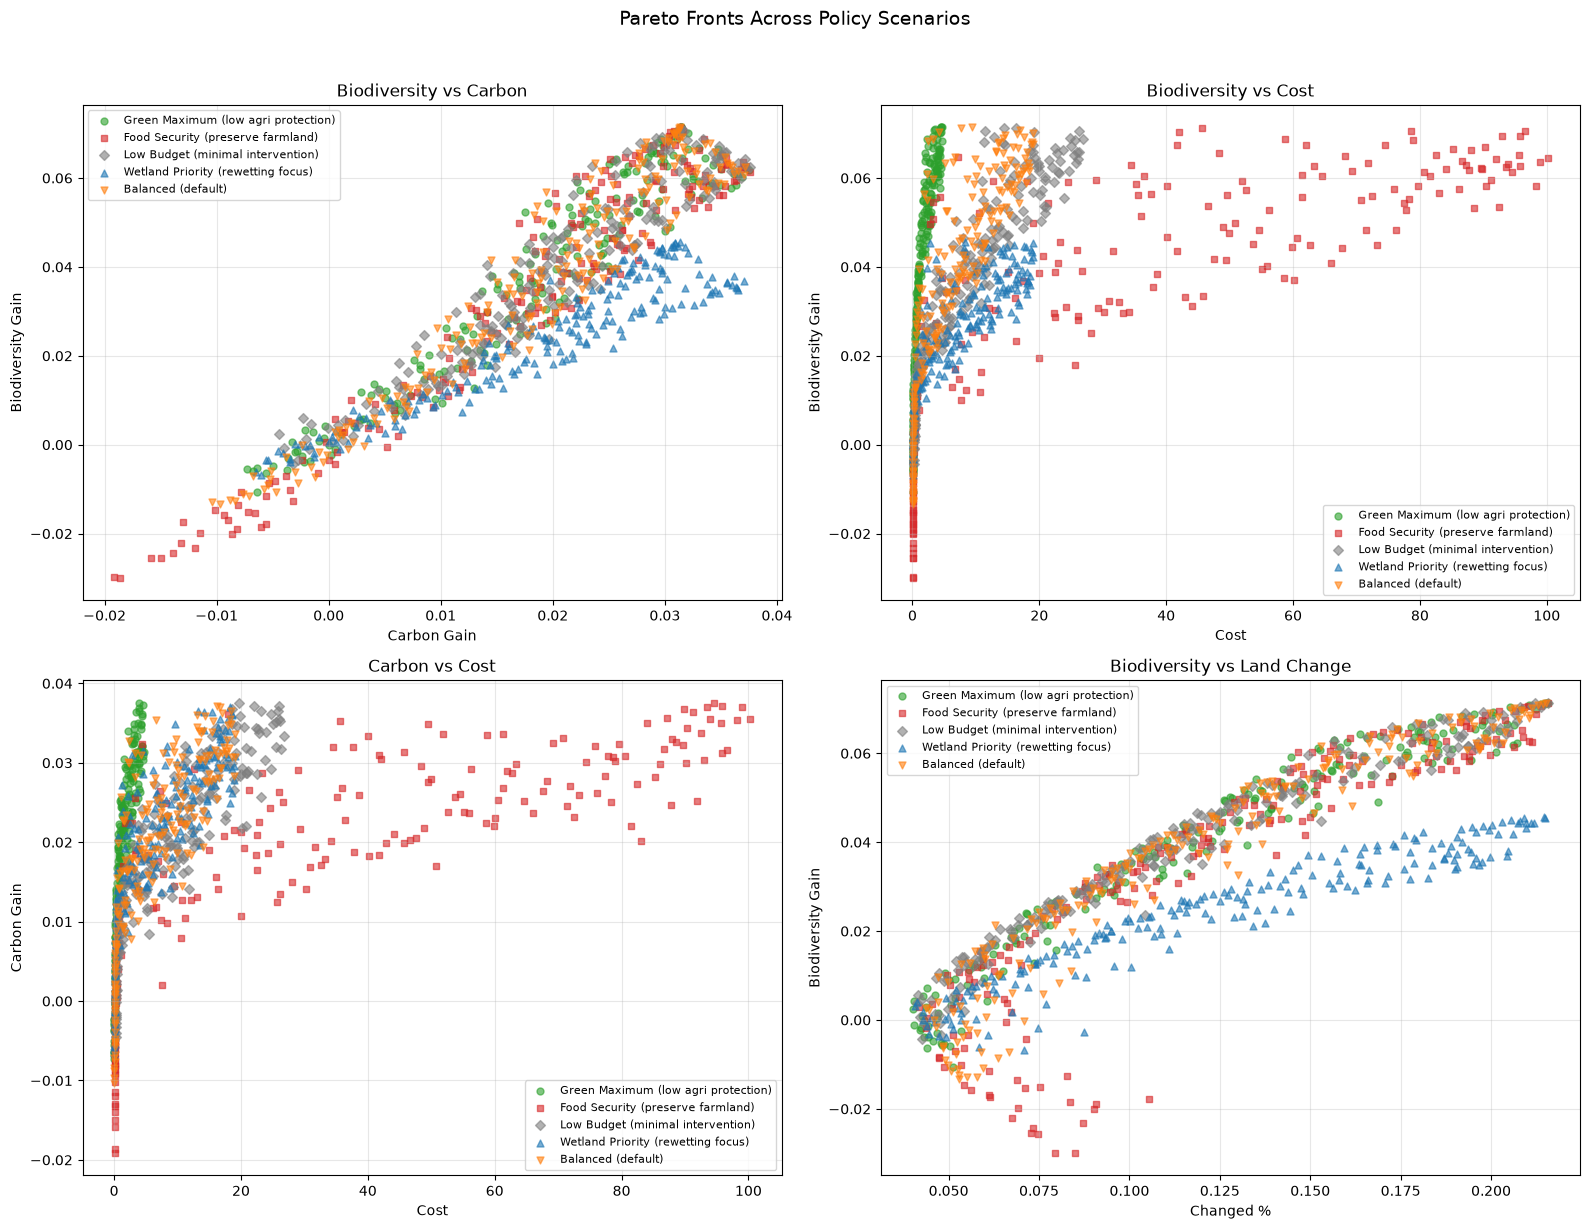

In [7]:
colors = {"green_maximum": "tab:green", "food_security": "tab:red",
           "low_budget": "tab:gray", "wetland_priority": "tab:blue",
           "balanced": "tab:orange"}
markers = {"green_maximum": "o", "food_security": "s",
            "low_budget": "D", "wetland_priority": "^", "balanced": "v"}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bio vs Carbon
ax = axes[0, 0]
for name, pdf in pareto_dfs.items():
    ax.scatter(pdf["carbon_gain"], pdf["biodiversity_gain"],
               alpha=0.6, s=25, label=SCENARIOS[name],
               color=colors[name], marker=markers[name])
ax.set_xlabel("Carbon Gain"); ax.set_ylabel("Biodiversity Gain")
ax.set_title("Biodiversity vs Carbon"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Bio vs Cost
ax = axes[0, 1]
for name, pdf in pareto_dfs.items():
    ax.scatter(pdf["cost"], pdf["biodiversity_gain"],
               alpha=0.6, s=25, label=SCENARIOS[name],
               color=colors[name], marker=markers[name])
ax.set_xlabel("Cost"); ax.set_ylabel("Biodiversity Gain")
ax.set_title("Biodiversity vs Cost"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Carbon vs Cost
ax = axes[1, 0]
for name, pdf in pareto_dfs.items():
    ax.scatter(pdf["cost"], pdf["carbon_gain"],
               alpha=0.6, s=25, label=SCENARIOS[name],
               color=colors[name], marker=markers[name])
ax.set_xlabel("Cost"); ax.set_ylabel("Carbon Gain")
ax.set_title("Carbon vs Cost"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Bio vs Change%
ax = axes[1, 1]
for name, pdf in pareto_dfs.items():
    ax.scatter(pdf["changed_pct"], pdf["biodiversity_gain"],
               alpha=0.6, s=25, label=SCENARIOS[name],
               color=colors[name], marker=markers[name])
ax.set_xlabel("Changed %"); ax.set_ylabel("Biodiversity Gain")
ax.set_title("Biodiversity vs Land Change"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Pareto Fronts Across Policy Scenarios", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary table

In [8]:
summary_rows = []
for name, pdf in pareto_dfs.items():
    best_bio = pdf.loc[pdf["biodiversity_gain"].idxmax()]
    summary_rows.append({
        "Scenario": SCENARIOS[name],
        "Bio (best)": best_bio["biodiversity_gain"],
        "Carbon (best bio)": best_bio["carbon_gain"],
        "Cost (best bio)": best_bio["cost"],
        "Change% (best bio)": best_bio["changed_pct"],
        "Front size": len(pdf),
        "Time (s)": results[name]["time"],
    })
summary = pd.DataFrame(summary_rows).set_index("Scenario")
print(summary.to_string(float_format="{:.4f}".format))

                                     Bio (best)  Carbon (best bio)  Cost (best bio)  Change% (best bio)  Front size  Time (s)
Scenario                                                                                                                     
Green Maximum (low agri protection)      0.0714             0.0314           4.4485              0.2154         200  721.8000
Food Security (preserve farmland)        0.0714             0.0314          45.6612              0.2157         200  714.7219
Low Budget (minimal intervention)        0.0714             0.0314          16.3864              0.2121         200  726.8736
Wetland Priority (rewetting focus)       0.0457             0.0313           8.2457              0.2146         200  723.6641
Balanced (default)                       0.0714             0.0314           9.4304              0.2152         200  711.5385


## Action maps (best biodiversity policy per scenario)

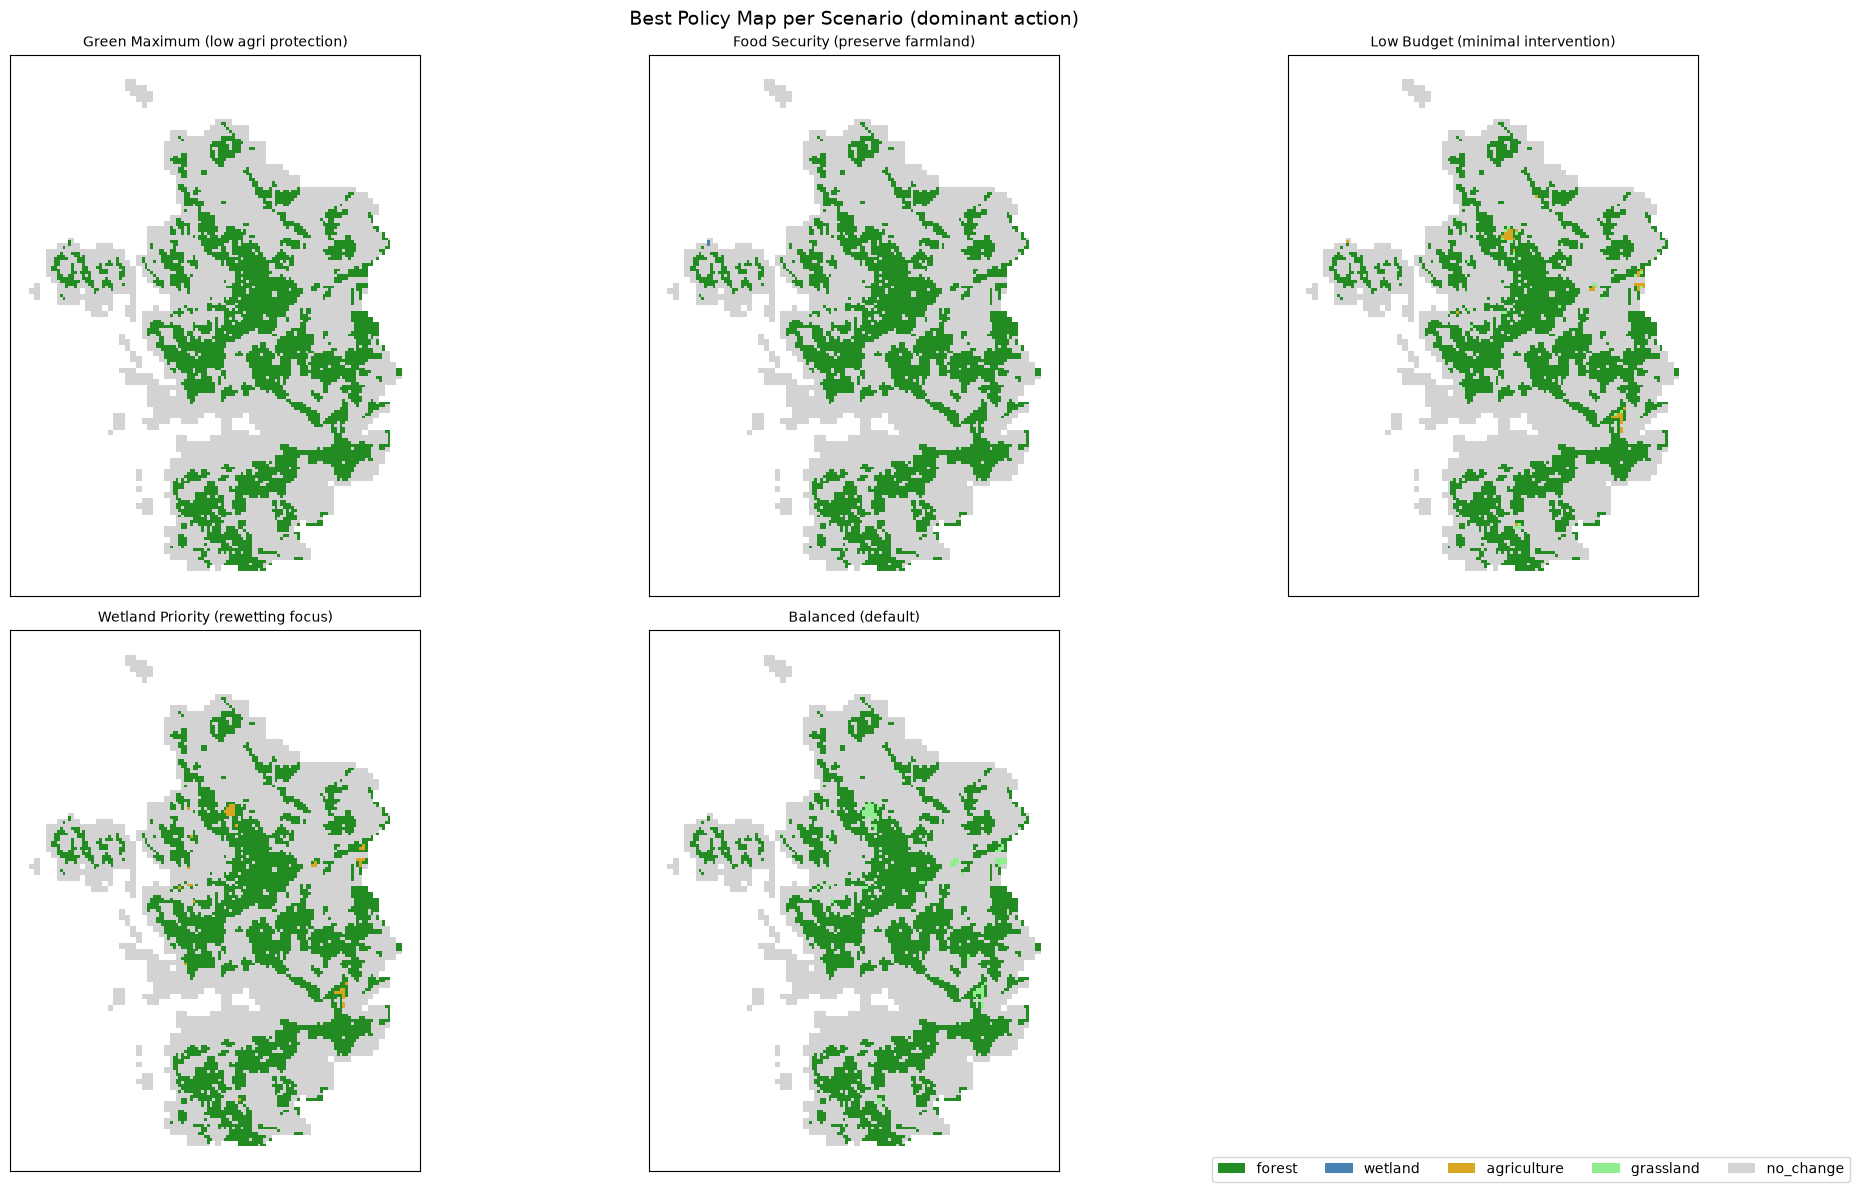

In [9]:
# Compute best policy targets for each scenario
groups = ["forest", "wetland", "agriculture", "grassland"]

features = features_df[FEATURE_COLUMNS].values.astype(np.float32)
feat_mean = features.mean(axis=0)
feat_std = features.std(axis=0)
feat_std[feat_std == 0] = 1.0
feat_norm = (features - feat_mean) / feat_std

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

for idx, (name, data) in enumerate(results.items()):
    if idx >= 6:
        break
    ax = axes_flat[idx]

    # Get best biodiversity policy
    pdf = pareto_dfs[name]
    best_idx = pdf["biodiversity_gain"].idxmax()
    front0 = [p for p in data["pop"] if p.rank == 0]
    best_policy = front0[best_idx]

    # Compute delta
    targets = best_policy.prescribe(feat_norm)
    current = np.column_stack([features_df[f"{g}_pct"].values for g in groups])
    urban = features_df["urban_pct"].values
    water = features_df["water_pct"].values
    available = np.clip(1.0 - urban - water, 0, 1)
    tgt_sum = targets.sum(axis=1, keepdims=True)
    tgt_sum = np.where(tgt_sum > 0, tgt_sum, 1.0)
    targets_norm = targets / tgt_sum * available[:, None]
    delta = targets_norm - current

    # Apply constraints for visualization
    protected_threshold = 0.15
    is_protected = features_df["protected_overlap_pct"].values > protected_threshold
    delta[is_protected] = 0
    wetland_loss_mask = delta[:, 1] < 0
    delta[wetland_loss_mask, 1] = 0

    # Dominant action
    change_intensity = np.abs(delta).sum(axis=1) / 2.0
    dominant = np.array(groups)[delta.argmax(axis=1)]
    dominant[change_intensity < 0.05] = "no_change"

    # Map
    map_df = grid.copy()
    map_df["action"] = dominant

    color_map = {"forest": "#228B22", "wetland": "#4682B4",
                 "agriculture": "#DAA520", "grassland": "#90EE90", "no_change": "#D3D3D3"}
    for action, color in color_map.items():
        subset = map_df[map_df["action"] == action]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor="none")

    ax.set_title(f"{SCENARIOS[name]}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

# Hide unused subplot
if len(results) < 6:
    axes_flat[5].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=a) for a, c in color_map.items()]
fig.legend(handles=legend_elements, loc="lower right", fontsize=10, ncol=5)

plt.suptitle("Best Policy Map per Scenario (dominant action)", fontsize=14)
plt.tight_layout()
plt.show()

## Change intensity comparison

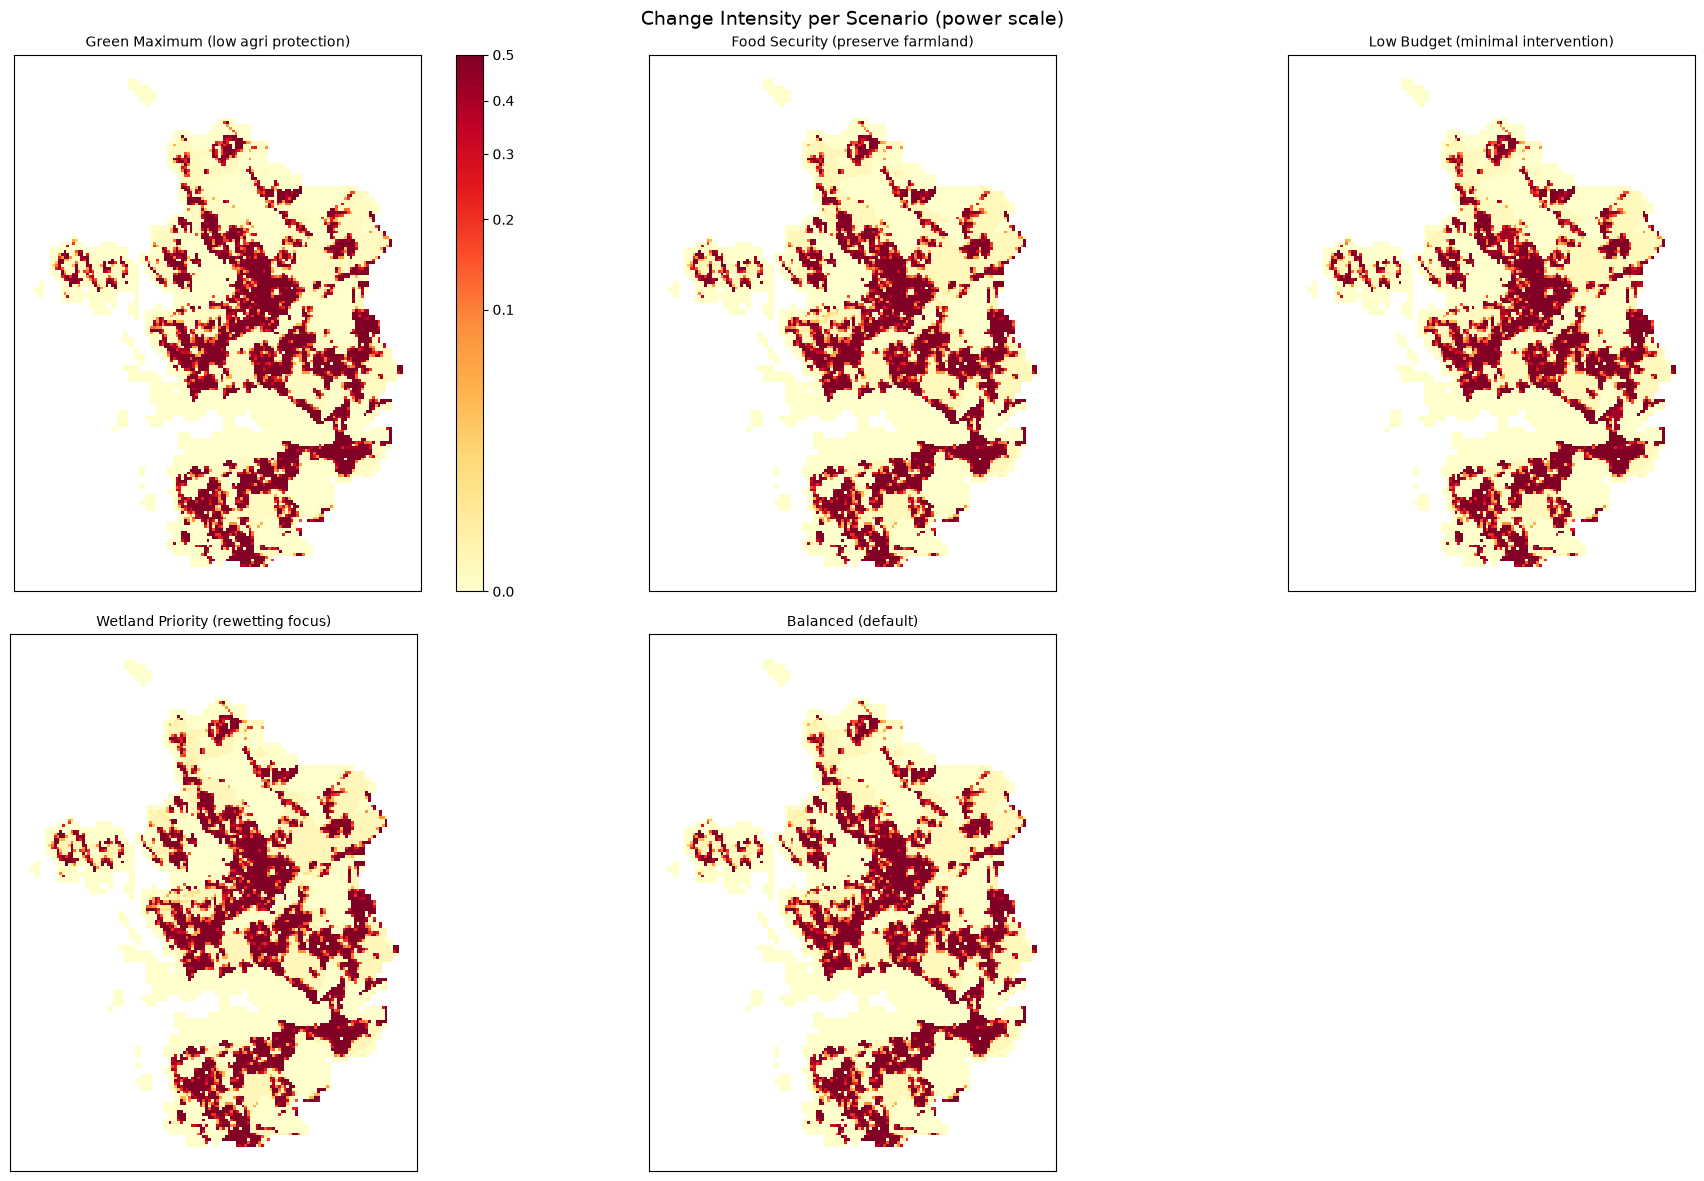

In [10]:
from matplotlib.colors import PowerNorm

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

for idx, (name, data) in enumerate(results.items()):
    if idx >= 6:
        break
    ax = axes_flat[idx]

    # Get best policy
    pdf = pareto_dfs[name]
    best_idx = pdf["biodiversity_gain"].idxmax()
    front0 = [p for p in data["pop"] if p.rank == 0]
    best_policy = front0[best_idx]

    targets = best_policy.prescribe(feat_norm)
    current = np.column_stack([features_df[f"{g}_pct"].values for g in groups])
    urban = features_df["urban_pct"].values
    water = features_df["water_pct"].values
    available = np.clip(1.0 - urban - water, 0, 1)
    tgt_sum = targets.sum(axis=1, keepdims=True)
    tgt_sum = np.where(tgt_sum > 0, tgt_sum, 1.0)
    targets_norm = targets / tgt_sum * available[:, None]
    delta = targets_norm - current

    # Constraints
    is_protected = features_df["protected_overlap_pct"].values > 0.15
    delta[is_protected] = 0

    intensity = np.abs(delta).sum(axis=1) / 2.0
    map_df = grid.copy()
    map_df["intensity"] = intensity

    map_df.plot(column="intensity", ax=ax, cmap="YlOrRd",
                norm=PowerNorm(gamma=0.4, vmin=0, vmax=0.5),
                legend=(idx == 0))
    ax.set_title(f"{SCENARIOS[name]}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

if len(results) < 6:
    axes_flat[5].set_visible(False)

plt.suptitle("Change Intensity per Scenario (power scale)", fontsize=14)
plt.tight_layout()
plt.show()

## Save results

In [ ]:
# Save pareto data for later analysis
all_pareto = []
for name, pdf in pareto_dfs.items():
    pdf_copy = pdf.copy()
    pdf_copy["scenario"] = name
    all_pareto.append(pdf_copy)

pd.concat(all_pareto).to_parquet(OUTPUT_DIR / "scenario_comparison.parquet", index=False)
print(f"Saved Pareto metrics to {OUTPUT_DIR / 'scenario_comparison.parquet'}")

# Save per-cell action maps as GeoPackage (for interactive visualizations)
maps_dir = OUTPUT_DIR / "scenario_maps"
maps_dir.mkdir(exist_ok=True)

for name, data in results.items():
    pdf = pareto_dfs[name]
    best_idx = pdf["biodiversity_gain"].idxmax()
    front0 = [p for p in data["pop"] if p.rank == 0]
    best_policy = front0[best_idx]

    targets = best_policy.prescribe(feat_norm)
    current = np.column_stack([features_df[f"{g}_pct"].values for g in groups])
    urban = features_df["urban_pct"].values
    water = features_df["water_pct"].values
    available = np.clip(1.0 - urban - water, 0, 1)
    tgt_sum = targets.sum(axis=1, keepdims=True)
    tgt_sum = np.where(tgt_sum > 0, tgt_sum, 1.0)
    targets_norm = targets / tgt_sum * available[:, None]
    delta = targets_norm - current

    # Apply constraints
    is_protected = features_df["protected_overlap_pct"].values > 0.15
    delta[is_protected] = 0
    targets_norm[is_protected] = current[is_protected]
    wetland_loss_mask = delta[:, 1] < 0
    delta[wetland_loss_mask, 1] = 0
    targets_norm[wetland_loss_mask, 1] = current[wetland_loss_mask, 1]

    # Build map dataframe
    map_gdf = grid[["cell_id", "geometry"]].copy()
    map_gdf["change_intensity"] = np.abs(delta).sum(axis=1) / 2.0
    dominant = np.array(groups)[delta.argmax(axis=1)]
    dominant[map_gdf["change_intensity"].values < 0.05] = "no_change"
    map_gdf["action"] = dominant
    for i, g in enumerate(groups):
        map_gdf[f"current_{g}"] = current[:, i]
        map_gdf[f"target_{g}"] = targets_norm[:, i]
        map_gdf[f"delta_{g}"] = delta[:, i]

    map_gdf.to_file(maps_dir / f"{name}.gpkg", driver="GPKG")

print(f"Saved {len(results)} scenario maps to {maps_dir}/")
print("Each contains: cell_id, geometry, action, change_intensity, current/target/delta per group")

Saved Pareto metrics to ..\data\processed\learned_carbon\scenario_comparison.parquet
